# Hệ Thống Hỏi Đáp Pháp Luật – Bộ Luật Dân Sự 2015
## RAG + Fine-tuning Qwen2.5-3B-Instruct (QLoRA)

### Kiến trúc tổng thể
```
Input Query
    │
    ▼
┌─────────────────────────────────────┐
│  MemPalace-Inspired Metadata Scoper │  ← phân loại vào Phần/Chương
└─────────────────────────────────────┘
    │
    ▼
┌──────────────────┐
│  Vector Retriever│  ← FAISS + Chroma, top-k trong scope
└──────────────────┘
    │  top-k chunks
    ▼
┌──────────────────────────────┐
│  LLM (base hoặc fine-tuned) │  ← Qwen2.5-3B-Instruct
└──────────────────────────────┘
    │
    ▼
Answer + Legal Citation
```

### 4 cấu hình thực nghiệm
| | Không RAG | Có RAG |
|---|---|---|
| **LLM gốc** | A | B |
| **LLM fine-tuned** | C | D |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Cài đặt thư viện

In [2]:
import subprocess, sys

packages = [
    "torch>=2.1",
    "transformers>=4.44",
    "accelerate>=0.26",
    "peft>=0.12",
    "bitsandbytes>=0.43",
    "trl==0.19.1",       # Ghim phiên bản 0.19.1 để giữ DataCollatorForCompletionOnlyLM
    "datasets>=2.18",
    "sentence-transformers>=3.0",
    "faiss-cpu",
    "chromadb>=0.5",
    "evaluate",
    "bert-score",
    "rouge-score",
    "nltk",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "tqdm",
    "underthesea",
    "pyvi",
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

print("Đã cài đặt xong tất cả thư viện.")

Đã cài đặt xong tất cả thư viện.


## 2. Import & Cấu hình toàn cục

In [3]:
import json, os, re, random, warnings, time
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments,
    GenerationConfig,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM
from datasets import Dataset

from sentence_transformers import SentenceTransformer
import faiss

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

warnings.filterwarnings("ignore")
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


In [4]:

# ── Đường dẫn ────────────────────────────────────────────────────────────────
DATA_DIR      = Path("/content/drive/MyDrive/AI/qwen")
CHUNKS_PATH   = DATA_DIR / "luat_chunk.json"
PARSED_PATH   = DATA_DIR / "luat_parse.json"
OUTPUT_DIR    = DATA_DIR / "outputs"
FINETUNED_DIR = DATA_DIR / "finetuned"
OUTPUT_DIR.mkdir(exist_ok=True)
FINETUNED_DIR.mkdir(exist_ok=True)

# ── Dataset paths (train / val / test đã chuẩn bị sẵn) ────────────────────
TRAIN_PATH = DATA_DIR / "train_formatted.json"
VALID_PATH = DATA_DIR / "valid_formatted.json"
TEST_PATH  = DATA_DIR / "test_formatted.json"

# ── Model config ──────────────────────────────────────────────────────────────
BASE_MODEL_ID  = "Qwen/Qwen2.5-3B-Instruct"
EMBED_MODEL_ID = "keepitreal/vietnamese-sbert"

TOP_K = 5

# ── System prompt (phải KHỚP với system prompt trong dataset train/val/test) ──
# Kiểm tra bằng: json.load(open(TRAIN_PATH))[0]["text"].split("<|im_start|>")[1]
SYSTEM_PROMPT = (
    "Bạn là trợ lý pháp lý chuyên về Bộ luật Dân sự Việt Nam 2015. "
    "Trả lời chính xác, ngắn gọn dựa trên các điều khoản cụ thể của luật. "
    "Nếu câu hỏi là đúng/sai, hãy kết luận rõ ràng rồi giải thích."
)

print("Cấu hình toàn cục đã sẵn sàng.")

Cấu hình toàn cục đã sẵn sàng.


In [5]:
import os
path = '/content/drive/MyDrive/AI/qwen/luat_chunk.json'
print("File có tồn tại không:", os.path.exists(CHUNKS_PATH))
print("File có tồn tại không:", os.path.exists(PARSED_PATH))
print(FINETUNED_DIR)
print("File có tồn tại không:", os.path.exists(FINETUNED_DIR))
print(OUTPUT_DIR)

File có tồn tại không: True
File có tồn tại không: True
/content/drive/MyDrive/AI/qwen/finetuned
File có tồn tại không: True
/content/drive/MyDrive/AI/qwen/outputs


## 3. Tải & Khám phá Dữ liệu

Tổng số chunks: 711
Parsed records: 721

Phân bố chunk_type:
chunk_type
dieu_nguyen    676
khoan           35
Name: count, dtype: int64


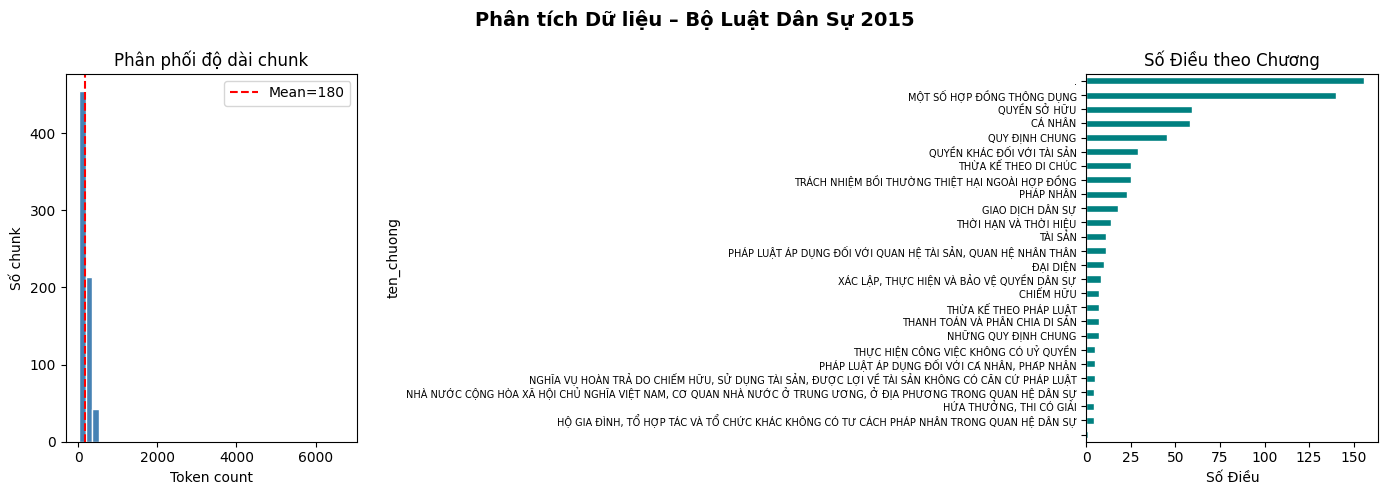

In [6]:
# ── Tải chunks ──────────────────────────────────────────────────────────────
with open(CHUNKS_PATH, encoding="utf-8") as f:
    chunks: List[Dict] = json.load(f)

with open(PARSED_PATH, encoding="utf-8") as f:
    parsed: List[Dict] = json.load(f)

print(f"Tổng số chunks: {len(chunks)}")
print(f"Parsed records: {len(parsed)}")

df = pd.DataFrame(chunks)
print("\nPhân bố chunk_type:")
print(df["chunk_type"].value_counts())

# ── Biểu đồ ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phân tích Dữ liệu – Bộ Luật Dân Sự 2015", fontsize=14, fontweight="bold")

axes[0].hist(df["token_count"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(df["token_count"].mean(), color="red", linestyle="--",
                label=f"Mean={df['token_count'].mean():.0f}")
axes[0].set_xlabel("Token count"); axes[0].set_ylabel("Số chunk")
axes[0].set_title("Phân phối độ dài chunk"); axes[0].legend()

chuong_counts = df.groupby("ten_chuong")["so_dieu"].nunique().sort_values()
chuong_counts.plot(kind="barh", ax=axes[1], color="teal", edgecolor="white")
axes[1].set_xlabel("Số Điều"); axes[1].set_title("Số Điều theo Chương")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Dataset & Phân tích

In [7]:
# ── Load train / valid / test ────────────────────────────────────────────────
def load_json(path: Path) -> List[Dict]:
    with open(path, encoding="utf-8") as f:
        return json.load(f)

train_data = load_json(TRAIN_PATH)
valid_data = load_json(VALID_PATH)
test_data  = load_json(TEST_PATH)

print(f"Train : {len(train_data):>5} mẫu")
print(f"Valid : {len(valid_data):>5} mẫu")
print(f"Test  : {len(test_data):>5} mẫu")
print(f"Total : {len(train_data)+len(valid_data)+len(test_data):>5} mẫu")

# ── Kiểm tra format ──────────────────────────────────────────────────────────
sample = train_data[0]
print("\nKeys:", list(sample.keys()))
print("\nSample text (200 ký tự đầu):")
print(sample["text"][:200])
print("\nCategories:")
from collections import Counter
cats = Counter(d["category"] for d in train_data)
for cat, cnt in sorted(cats.items(), key=lambda x: -x[1]):
    print(f"  {cat:<30}: {cnt}")

# Kiểm tra system prompt khớp
def extract_system_prompt(text: str) -> str:
    try:
        parts = text.split("<|im_start|>")
        sys_part = parts[1]  # "system\n....<|im_end|>"
        return sys_part.split("\n", 1)[1].split("<|im_end|>")[0]
    except Exception:
        return ""

detected_sp = extract_system_prompt(train_data[0]["text"])
print("\nSystem prompt từ dataset:")
print(detected_sp)
assert detected_sp == SYSTEM_PROMPT, (
    "SYSTEM_PROMPT trong config KHÔNG khớp với dataset!\n"
    f"  Config: {SYSTEM_PROMPT}\n"
    f"  Dataset: {detected_sp}"
)
print("\nSystem prompt khớp – sẵn sàng fine-tune.")

Train :  2496 mẫu
Valid :   534 mẫu
Test  :   536 mẫu
Total :  3566 mẫu

Keys: ['text', 'category', 'qa_id']

Sample text (200 ký tự đầu):
<|im_start|>system
Bạn là trợ lý pháp lý chuyên về Bộ luật Dân sự Việt Nam 2015. Trả lời chính xác, ngắn gọn dựa trên các điều khoản cụ thể của luật. Nếu câu hỏi là đúng/sai, hãy kết luận rõ ràng rồi 

Categories:
  quy_dinh_chung                : 547
  tai_san_so_huu                : 436
  hop_dong                      : 426
  giao_dich_dan_su              : 297
  thua_ke                       : 251
  quyen_nhan_than               : 218
  phap_nhan                     : 130
  boi_thuong_thiet_hai          : 77
  phap_luat_ap_dung             : 74
  nang_luc_hanh_vi              : 27
  dai_dien                      : 12
  giam_ho                       : 1

System prompt từ dataset:
Bạn là trợ lý pháp lý chuyên về Bộ luật Dân sự Việt Nam 2015. Trả lời chính xác, ngắn gọn dựa trên các điều khoản cụ thể của luật. Nếu câu hỏi là đúng/sai, hãy kết luận r

## 5. Cấu trúc Dữ liệu & Index Pháp Lý

In [8]:
@dataclass
class LegalChunk:
    chunk_id:    str
    content:     str
    so_dieu:     int
    ten_dieu:    str
    so_phan:     int
    ten_phan:    str
    so_chuong:   int
    ten_chuong:  str
    so_muc:      Optional[int]
    ten_muc:     Optional[str]
    chunk_type:  str
    token_count: int
    related_chunks: List[str] = field(default_factory=list)

    def legal_citation(self) -> str:
        cite = f"Điều {self.so_dieu} – {self.ten_dieu}"
        if self.ten_muc:
            cite += f" (Mục {self.so_muc}: {self.ten_muc})"
        cite += f", Chương {self.so_chuong}: {self.ten_chuong}"
        cite += f", Phần {self.so_phan}: {self.ten_phan}"
        cite += ", Bộ Luật Dân Sự 2015 (Luật số 91/2015/QH13)"
        return cite

legal_chunks: List[LegalChunk] = [
    LegalChunk(
        chunk_id=c["chunk_id"], content=c["content"],
        so_dieu=c["so_dieu"], ten_dieu=c["ten_dieu"],
        so_phan=c["so_phan"], ten_phan=c["ten_phan"],
        so_chuong=c["so_chuong"], ten_chuong=c["ten_chuong"],
        so_muc=c.get("so_muc"), ten_muc=c.get("ten_muc"),
        chunk_type=c["chunk_type"], token_count=c.get("token_count", 0),
        related_chunks=c.get("related_chunks", []),
    )
    for c in chunks
]

chuong_index: Dict[int, List[LegalChunk]] = defaultdict(list)
phan_index:   Dict[int, List[LegalChunk]] = defaultdict(list)
dieu_index:   Dict[int, LegalChunk]       = {}

for lc in legal_chunks:
    chuong_index[lc.so_chuong].append(lc)
    phan_index[lc.so_phan].append(lc)
    if lc.chunk_type == "dieu_nguyen" and lc.so_dieu not in dieu_index:
        dieu_index[lc.so_dieu] = lc

print(f"Parsed {len(legal_chunks)} LegalChunks")
print(f"  {len(phan_index)} Phần | {len(chuong_index)} Chương | {len(dieu_index)} Điều")

Parsed 711 LegalChunks
  6 Phần | 28 Chương | 676 Điều


## 6. Embedding Model & FAISS Vector Store

In [9]:
class EmbeddingEngine:
    def __init__(self, model_id: str = EMBED_MODEL_ID, device: str = DEVICE):
        print(f"Tải embedding model: {model_id}")
        self.model = SentenceTransformer(model_id, device=device)
        self.dim   = self.model.get_sentence_embedding_dimension()
        print(f"Embedding dim: {self.dim}")

    def encode(self, texts: List[str], batch_size: int = 64,
               normalize: bool = True, show_progress: bool = True) -> np.ndarray:
        return self.model.encode(
            texts, batch_size=batch_size,
            normalize_embeddings=normalize,
            show_progress_bar=show_progress,
        )


class FAISSVectorStore:
    def __init__(self, dim: int):
        self.dim = dim
        self.global_index  = faiss.IndexFlatIP(dim)
        self.global_chunks: List[LegalChunk] = []
        self.chuong_indexes: Dict[int, faiss.IndexFlatIP] = {}
        self.chuong_chunks:  Dict[int, List[LegalChunk]]  = {}

    def build(self, chunks: List[LegalChunk], embeddings: np.ndarray):
        vecs = embeddings.astype(np.float32)
        self.global_index.add(vecs)
        self.global_chunks = chunks

        chuong_to_indices = defaultdict(list)
        for i, c in enumerate(chunks):
            chuong_to_indices[c.so_chuong].append(i)

        for cid, idxs in chuong_to_indices.items():
            sub = faiss.IndexFlatIP(self.dim)
            sub.add(vecs[idxs])
            self.chuong_indexes[cid] = sub
            self.chuong_chunks[cid]  = [chunks[i] for i in idxs]

        print(f"FAISS: {self.global_index.ntotal} vectors, {len(self.chuong_indexes)} sub-indexes")

    def search_global(self, q: np.ndarray, k: int = TOP_K):
        D, I = self.global_index.search(q.reshape(1,-1).astype(np.float32), k)
        return [(self.global_chunks[i], float(D[0][j])) for j, i in enumerate(I[0]) if i >= 0]

    def search_scoped(self, q: np.ndarray, chuong_ids: List[int], k: int = TOP_K):
        results = []
        for cid in chuong_ids:
            if cid not in self.chuong_indexes:
                continue
            sub = self.chuong_indexes[cid]
            D, I = sub.search(q.reshape(1,-1).astype(np.float32), min(k, sub.ntotal))
            for j, i in enumerate(I[0]):
                if i >= 0:
                    results.append((self.chuong_chunks[cid][i], float(D[0][j])))
        results.sort(key=lambda x: x[1], reverse=True)
        seen, unique = set(), []
        for c, s in results:
            if c.chunk_id not in seen:
                seen.add(c.chunk_id); unique.append((c, s))
        return unique[:k]

    def save(self, path: str): faiss.write_index(self.global_index, path)
    def load(self, path: str): self.global_index = faiss.read_index(path)


embed_engine = EmbeddingEngine()

EMBED_CACHE = OUTPUT_DIR / "chunk_embeddings.npy"
if EMBED_CACHE.exists():
    print("Tải embeddings từ cache...")
    all_embeddings = np.load(str(EMBED_CACHE))
else:
    print("Tính embeddings (lần đầu – lưu cache)...")
    all_embeddings = embed_engine.encode([c.content for c in legal_chunks])
    np.save(str(EMBED_CACHE), all_embeddings)

faiss_store = FAISSVectorStore(dim=embed_engine.dim)
faiss_store.build(legal_chunks, all_embeddings)
faiss_store.save(str(OUTPUT_DIR / "faiss_global.index"))
print("FAISS vector store đã sẵn sàng.")

Tải embedding model: keepitreal/vietnamese-sbert


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim: 768
Tải embeddings từ cache...
FAISS: 711 vectors, 28 sub-indexes
FAISS vector store đã sẵn sàng.


## 7. MemPalace Scoper & RAG Retriever

In [10]:
from sentence_transformers import CrossEncoder

# ── 1. Scoper (Giữ nguyên như cũ) ─────────────────────────────────────────────
class MemPalaceScoper:
    DOMAIN_KEYWORDS: Dict[int, List[str]] = {
        1:  ["phạm vi", "nguyên tắc", "áp dụng", "điều chỉnh", "luật"],
        3:  ["cá nhân", "năng lực", "hành vi", "họ tên", "nơi cư trú",
             "mất tích", "chết", "giám hộ", "thông tin cá nhân", "quyền nhân thân"],
        4:  ["pháp nhân", "doanh nghiệp", "tổ chức", "thành lập", "giải thể"],
        5:  ["hộ gia đình", "tổ hợp tác", "nhà nước", "cộng đồng"],
        6:  ["tài sản", "vật", "tiền", "giấy tờ", "quyền tài sản",
             "động sản", "bất động sản", "hoa lợi", "lợi tức"],
        7:  ["giao dịch", "hợp đồng", "vô hiệu", "điều kiện", "cam kết",
             "đề nghị", "chấp nhận", "ý chí", "giả tạo", "nhầm lẫn"],
        8:  ["đại diện", "ủy quyền", "người đại diện"],
        9:  ["thời hạn", "thời hiệu", "thời gian", "hết hạn"],
        14: ["sở hữu", "chiếm hữu", "sử dụng", "định đoạt", "chủ sở hữu"],
        15: ["nghĩa vụ", "thực hiện", "vi phạm", "chấm dứt nghĩa vụ"],
        16: ["hợp đồng", "ký kết", "thực hiện hợp đồng", "chấm dứt",
             "vi phạm hợp đồng", "phạt vi phạm", "bồi thường thiệt hại",
             "mua bán", "thuê", "vay", "tặng cho", "dịch vụ"],
        20: ["thừa kế", "di chúc", "di sản", "người thừa kế"],
        21: ["hàng thừa kế", "theo pháp luật", "chia đều"],
        22: ["di chúc", "người lập di chúc", "nội dung di chúc"],
        24: ["bồi thường", "thiệt hại", "lỗi", "trách nhiệm", "tai nạn",
             "súc vật", "công trình", "nguồn nguy hiểm"],
    }

    def __init__(self, embed_engine: EmbeddingEngine,
                 chuong_index_map: Dict[int, List[LegalChunk]]):
        self.embed_engine     = embed_engine
        self.chuong_index_map = chuong_index_map
        self.chuong_names = {
            cid: cs[0].ten_chuong for cid, cs in chuong_index_map.items()
        }
        ids_sorted   = sorted(self.chuong_names.keys())
        texts        = [self.chuong_names[c] for c in ids_sorted]
        self._ids    = ids_sorted
        self._embeds = embed_engine.encode(texts, show_progress=False)

    def scope(self, query: str, top_chuong: int = 3) -> List[int]:
        query_lower = query.lower()
        scores: Dict[int, float] = defaultdict(float)
        for cid, kws in self.DOMAIN_KEYWORDS.items():
            for kw in kws:
                if kw in query_lower:
                    scores[cid] += 1.0 + len(kw.split()) * 0.1
        q_vec = self.embed_engine.encode([query], show_progress=False)
        sims  = (q_vec @ self._embeds.T).flatten()
        for i, cid in enumerate(self._ids):
            scores[cid] += float(sims[i]) * 2.0
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [cid for cid, _ in ranked[:top_chuong]]

# ── 2. Thêm class Reranker ───────────────────────────────────────────────────
class CrossEncoderReranker:
    def __init__(self, model_name: str = 'BAAI/bge-reranker-v2-m3', device: str = DEVICE):
        print(f"Tải Reranker model: {model_name}")
        # BAAI/bge-reranker-m3 là SOTA cho đa ngôn ngữ (bao gồm tiếng Việt)
        self.model = CrossEncoder(model_name, device=device)

    def rerank(self, query: str, retrieved_chunks: List[Tuple[LegalChunk, float]], top_k: int = 5) -> List[Tuple[LegalChunk, float]]:
        if not retrieved_chunks:
            return []

        # Format cặp (câu hỏi, ngữ cảnh) để đưa vào mô hình Cross-Encoder
        pairs = [[query, chunk.content] for chunk, _ in retrieved_chunks]

        # Tính điểm relevance (điểm càng cao, ngữ cảnh càng sát với câu hỏi)
        scores = self.model.predict(pairs)

        # Cập nhật lại điểm số (thay thế điểm FAISS bằng điểm Reranker)
        reranked_results = [(retrieved_chunks[i][0], float(scores[i])) for i in range(len(retrieved_chunks))]

        # Sắp xếp giảm dần theo điểm Reranker
        reranked_results.sort(key=lambda x: x[1], reverse=True)

        return reranked_results[:top_k]

# ── 3. Chỉnh sửa LegalRetriever ───────────────────────────────────────────────
class LegalRetriever:
    def __init__(self, faiss_store, embed_engine, scoper, reranker=None, fetch_k=20, top_k=TOP_K):
        self.faiss  = faiss_store
        self.embed  = embed_engine
        self.scoper = scoper
        self.reranker = reranker
        self.fetch_k = fetch_k # Số lượng chunk lấy thô từ FAISS
        self.top_k  = top_k    # Số lượng chunk trả về cuối cùng

    def retrieve(self, query: str, use_scoping: bool = True,
                 top_chuong: int = 3) -> List[Tuple[LegalChunk, float]]:

        q_vec = self.embed.encode([query], show_progress=False)

        # BƯỚC 1: Truy xuất thô từ FAISS (Lấy nhiều chunk hơn: fetch_k)
        if use_scoping:
            cids    = self.scoper.scope(query, top_chuong)
            results = self.faiss.search_scoped(q_vec, cids, k=self.fetch_k)
            if len(results) < self.fetch_k:
                seen = {c.chunk_id for c, _ in results}
                for c, s in self.faiss.search_global(q_vec, k=self.fetch_k):
                    if c.chunk_id not in seen:
                        results.append((c, s)); seen.add(c.chunk_id)
                    if len(results) >= self.fetch_k: break
        else:
            results = self.faiss.search_global(q_vec, k=self.fetch_k)

        results = results[:self.fetch_k]

        # BƯỚC 2: Xếp hạng lại (Reranking) bằng Cross-Encoder
        if self.reranker and len(results) > 0:
            results = self.reranker.rerank(query, results, top_k=self.top_k)
        else:
            # Nếu không có reranker, chỉ lấy top_k từ FAISS
            results = results[:self.top_k]

        return results

    def format_context(self, retrieved: List[Tuple[LegalChunk, float]]) -> str:
        return "\n".join(
            f"[{i}] {c.legal_citation()} (score={s:.3f})\n{c.content}\n"
            for i, (c, s) in enumerate(retrieved, 1)
        )

# ── 4. Khởi tạo Pipeline ──────────────────────────────────────────────────────
scoper    = MemPalaceScoper(embed_engine, chuong_index)

# Tải Reranker (Sẽ tốn khoảng 2GB VRAM để load BGE-M3 lên GPU)
reranker  = CrossEncoderReranker()

# Khởi tạo Retriever: Lấy top 20 từ FAISS, sau đó Rerank để chọn lại top 5
retriever = LegalRetriever(faiss_store, embed_engine, scoper, reranker=reranker, fetch_k=20, top_k=5)
print("Retriever (với Reranking) khởi tạo thành công.")

Tải Reranker model: BAAI/bge-reranker-v2-m3


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Retriever (với Reranking) khởi tạo thành công.


## 8. Prompt Templates (RAG & No-RAG)

> **Lưu ý**: System prompt trong template RAG phải **khớp hoàn toàn** với system prompt được dùng khi tạo dataset fine-tuning. Điều này đảm bảo model không bị confused giữa training distribution và inference distribution.

In [11]:
RAG_USER_TEMPLATE = """[NGỮ CẢNH PHÁP LÝ]
{context}

[CÂU HỎI]
{question}

[YÊU CẦU TRẢ LỜI]
Dựa vào các điều luật trên, hãy trả lời câu hỏi và trích dẫn rõ ràng số Điều làm căn cứ pháp lý."""

NO_RAG_USER_TEMPLATE = """{question}"""


def build_chatml_prompt(question: str, context: Optional[str] = None,
                        include_assistant_start: bool = True) -> str:
    """
    Build prompt theo chuẩn ChatML của Qwen2.5.
    - context=None  → No-RAG mode
    - context=str   → RAG mode
    - include_assistant_start=True → thêm '<|im_start|>assistant\n' ở cuối để trigger generation
    """
    if context is not None:
        user_msg = RAG_USER_TEMPLATE.format(context=context, question=question)
    else:
        user_msg = NO_RAG_USER_TEMPLATE.format(question=question)

    prompt = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{user_msg}<|im_end|>\n"
    )
    if include_assistant_start:
        prompt += "<|im_start|>assistant\n"
    return prompt


# Demo
demo_q = "Hợp đồng vô hiệu do giả tạo có những hậu quả pháp lý gì?"
retrieved = retriever.retrieve(demo_q)
context   = retriever.format_context(retrieved)
print("Prompt mẫu (RAG):")
print(build_chatml_prompt(demo_q, context)[:500], "...")

Prompt mẫu (RAG):
<|im_start|>system
Bạn là trợ lý pháp lý chuyên về Bộ luật Dân sự Việt Nam 2015. Trả lời chính xác, ngắn gọn dựa trên các điều khoản cụ thể của luật. Nếu câu hỏi là đúng/sai, hãy kết luận rõ ràng rồi giải thích.<|im_end|>
<|im_start|>user
[NGỮ CẢNH PHÁP LÝ]
[1] Điều 551 – Đơn phương chấm dứt thực hiện hợp đồng gia công (Mục 11: HỢP ĐỒNG GIA CÔNG), Chương 16: MỘT SỐ HỢP ĐỒNG THÔNG DỤNG, Phần 3: NGHĨA VỤ VÀ HỢP ĐỒNG, Bộ Luật Dân Sự 2015 (Luật số 91/2015/QH13) (score=0.002)
Điều 551. Đơn phương chấ ...


## 9. Fine-tuning Qwen2.5-3B-Instruct với QLoRA

### Những cải tiến chính về tokenization:

1. **`DataCollatorForCompletionOnlyLM`** – chỉ tính loss trên phần **assistant response**, không train trên system/user. Điều này tập trung gradient vào đúng phần cần học.

2. **Response template chính xác** – `<|im_start|>assistant\n` được encode thành token IDs, tránh ambiguity khi tokenizer encode trong context khác nhau.

3. **Pad token riêng biệt** – dùng `<|endoftext|>` thay vì `eos_token` làm pad để tránh model nhầm lẫn giữa padding và end-of-sequence.

4. **`padding_side="right"`** – bắt buộc cho training với causal LM để attention mask hoạt động đúng.

5. **`packing=False`** – tắt sequence packing để `DataCollatorForCompletionOnlyLM` tìm được response template chính xác trong từng sample.

In [12]:
SKIP_FINETUNING = True   # Đặt True nếu đã có model fine-tuned

# ── QLoRA config ──────────────────────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
)

MAX_SEQ_LEN = 2048

training_args = TrainingArguments(
    output_dir=str(FINETUNED_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    warmup_ratio=0.05,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",    # evaluate sau mỗi epoch
    load_best_model_at_end=True,    # giữ lại checkpoint tốt nhất
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    report_to="none",
    dataloader_pin_memory=False,
    group_by_length=True,           # nhóm các sample có độ dài tương tự → giảm padding
    seed=SEED,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# TOKENIZATION – Phần quan trọng nhất
# ══════════════════════════════════════════════════════════════════════════════

if not SKIP_FINETUNING and DEVICE == "cuda":

    # ── 1. Load tokenizer ────────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_ID,
        trust_remote_code=True,
        padding_side="right",   # bắt buộc cho training causal LM
    )

    # Qwen2.5 có sẵn pad_token là <|endoftext|> (id=151643) – KHÔNG dùng eos làm pad
    # vì eos (<|im_end|>, id=151645) cần để model biết khi nào kết thúc turn
    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({"pad_token": "<|endoftext|>"})
        print(f"Đã thêm pad_token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")
    else:
        print(f"Pad token: {tokenizer.pad_token!r} (id={tokenizer.pad_token_id})")
    print(f"EOS token: {tokenizer.eos_token!r} (id={tokenizer.eos_token_id})")

    # ── 2. Xác định Response Template ────────────────────────────────────────
    # DataCollatorForCompletionOnlyLM cần biết chuỗi token nào bắt đầu phần assistant
    # Qwen2.5 ChatML: "<|im_start|>assistant\n"
    # Encode STANDALONE để lấy token IDs chính xác (không bị ảnh hưởng BPE context)
    RESPONSE_TEMPLATE = "<|im_start|>assistant\n"
    response_template_ids = tokenizer.encode(
        RESPONSE_TEMPLATE, add_special_tokens=False
    )
    print(f"\nResponse template: {RESPONSE_TEMPLATE!r}")
    print(f"Response template IDs: {response_template_ids}")
    print(f"  (decoded): {[tokenizer.decode([t]) for t in response_template_ids]}")

    # Kiểm tra template xuất hiện trong sample thực
    sample_ids = tokenizer.encode(train_data[0]["text"], add_special_tokens=False)
    positions  = [
        i for i in range(len(sample_ids) - len(response_template_ids) + 1)
        if sample_ids[i:i+len(response_template_ids)] == response_template_ids
    ]
    print(f"\nTemplate xuất hiện {len(positions)} lần trong sample[0] tại vị trí: {positions}")
    assert len(positions) >= 1, "CẢNH BÁO: Template không tìm thấy trong sample! Kiểm tra lại format dataset."

    # ── 3. DataCollatorForCompletionOnlyLM ───────────────────────────────────
    # instruction_template: mask phần system+user (không tính loss)
    # response_template:    chỉ tính loss từ đây trở đi (phần assistant)
    data_collator = DataCollatorForCompletionOnlyLM(
        response_template=response_template_ids,
        tokenizer=tokenizer,
        mlm=False,
    )
    print("\nDataCollatorForCompletionOnlyLM đã cấu hình thành công.")

    # ── 4. Load model ─────────────────────────────────────────────────────────
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="sdpa" if torch.cuda.is_bf16_supported() else "eager",
    )
    model.config.use_cache = False
    model.config.pretraining_tp = 1

    # Resize embedding nếu đã thêm token mới
    model.resize_token_embeddings(len(tokenizer))

    # Wrap LoRA
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

elif SKIP_FINETUNING:
    print("Bỏ qua fine-tuning (SKIP_FINETUNING=True).")
else:
    print("Không có GPU – bỏ qua fine-tuning. Chạy trên Kaggle/Colab với GPU.")

Bỏ qua fine-tuning (SKIP_FINETUNING=True).


In [14]:
# ── 5. Tạo HuggingFace Dataset từ file JSON đã chuẩn bị sẵn ───────────────
if not SKIP_FINETUNING and DEVICE == "cuda":

    # Dùng trực tiếp train_formatted.json và valid_formatted.json
    hf_train = Dataset.from_list(train_data)
    hf_valid = Dataset.from_list(valid_data)

    print(f"Train dataset: {len(hf_train)} samples")
    print(f"Valid dataset: {len(hf_valid)} samples")

    # Kiểm tra một batch tokenization xem loss mask đúng không
    def verify_loss_mask(dataset, collator, tokenizer, n_check=2):
        """Kiểm tra DataCollator có mask đúng không: labels=-100 ở phần system+user, label thực ở assistant."""
        sample_batch = [dataset[i] for i in range(n_check)]
        # Tokenize
        encoded = [
            tokenizer(s["text"], truncation=True, max_length=MAX_SEQ_LEN,
                      return_tensors=None, add_special_tokens=False)
            for s in sample_batch
        ]
        batch = collator(encoded)
        for i, (inp, lab) in enumerate(zip(batch["input_ids"], batch["labels"])):
            n_active = (lab != -100).sum().item()
            # n_total  = (lab != -100 + lab == -100).numel()  # noqa — just len
            n_total  = len(lab)
            print(f"  Sample {i}: total={n_total} tokens | "
                  f"active_loss={n_active} ({100*n_active/n_total:.1f}%) | "
                  f"masked={n_total-n_active} ({100*(n_total-n_active)/n_total:.1f}%)")

    print("\nKiểm tra loss mask (active = phần assistant, masked = system+user):")
    verify_loss_mask(hf_train, data_collator, tokenizer)

In [15]:
from trl import SFTConfig, SFTTrainer

# 1. Chuyển đổi TrainingArguments cũ thành SFTConfig và gộp các tham số bị lỗi vào đây
sft_config = SFTConfig(
    output_dir=str(FINETUNED_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    warmup_ratio=0.05,
    learning_rate=2e-4,
    bf16=False,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    report_to="none",
    dataloader_pin_memory=False,
    group_by_length=True,
    seed=SEED,
    # --- CHUYỂN 3 THAM SỐ CỦA SFTTRAINER LÊN ĐÂY ---
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LEN,
    packing=False,
)

if not SKIP_FINETUNING and DEVICE == "cuda":

    trainer = SFTTrainer(
        model=model,
        args=sft_config,
        train_dataset=hf_train,
        eval_dataset=hf_valid,
        processing_class=tokenizer,
        data_collator=data_collator,
    )

    print("Bắt đầu Fine-tuning...")
    train_result = trainer.train()

    # In thống kê training
    print("\nTraining completed!")
    print(f"  Total steps : {train_result.global_step}")
    print(f"  Training loss: {train_result.training_loss:.4f}")

    # Lưu adapter
    trainer.save_model(str(FINETUNED_DIR))
    tokenizer.save_pretrained(str(FINETUNED_DIR))
    print(f"Fine-tuned model lưu tại: {FINETUNED_DIR}")

    # Lưu training history
    history = trainer.state.log_history
    with open(OUTPUT_DIR / "training_history.json", "w") as f:
        json.dump(history, f, indent=2)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


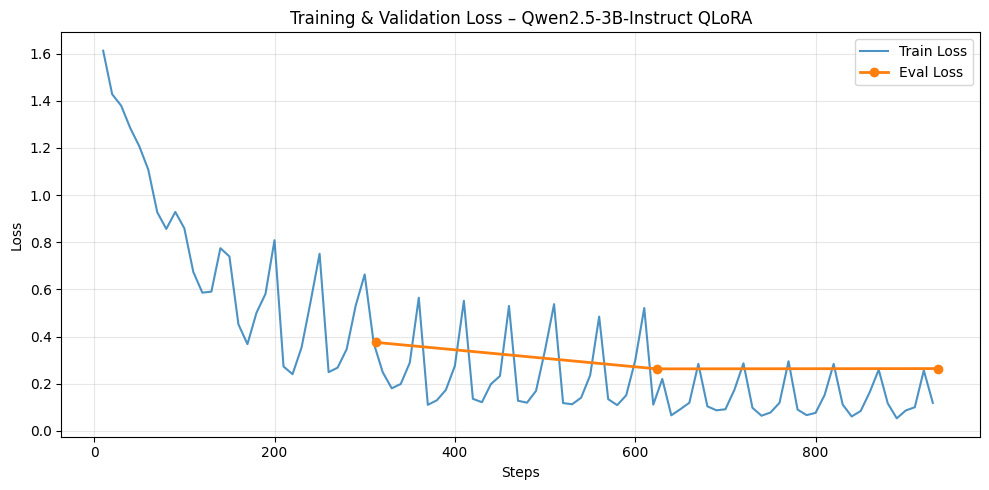

Loss curve đã lưu.


In [16]:
# ── 7. Vẽ Loss Curve sau training ──────────────────────────────────────────
if (OUTPUT_DIR / "training_history.json").exists():
    with open(OUTPUT_DIR / "training_history.json") as f:
        history = json.load(f)

    train_steps = [h["step"] for h in history if "loss" in h]
    train_loss  = [h["loss"] for h in history if "loss" in h]
    eval_steps  = [h["step"] for h in history if "eval_loss" in h]
    eval_loss   = [h["eval_loss"] for h in history if "eval_loss" in h]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(train_steps, train_loss, label="Train Loss", alpha=0.8)
    if eval_loss:
        ax.plot(eval_steps, eval_loss, label="Eval Loss", marker="o", linewidth=2)
    ax.set_xlabel("Steps"); ax.set_ylabel("Loss")
    ax.set_title("Training & Validation Loss – Qwen2.5-3B-Instruct QLoRA")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=150)
    plt.show()
    print("Loss curve đã lưu.")
else:
    print("Chưa có training history (chưa train hoặc skip).")

## 10. Load LLM & Inference Engine

In [17]:
class LLMInferenceEngine:
    """Wrapper để load và inference LLM (base hoặc fine-tuned + LoRA adapter)."""

    def __init__(self, model_path: str, use_qlora: bool = False,
                 lora_adapter_path: Optional[str] = None, device: str = DEVICE):
        self.device = device
        print(f"Loading model từ: {model_path}")

        # ── Tokenizer ─────────────────────────────────────────────────────────
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_path, trust_remote_code=True,
            padding_side="left",   # left-padding tốt hơn cho batch generation
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        # ── Model ─────────────────────────────────────────────────────────────
        load_kwargs = dict(trust_remote_code=True)
        if use_qlora and device == "cuda":
            load_kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_use_double_quant=True,
                bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16,
            )
            load_kwargs["device_map"] = "auto"
        elif device == "cuda":
            load_kwargs["torch_dtype"]  = torch.bfloat16
            load_kwargs["device_map"]   = "auto"
        else:
            load_kwargs["torch_dtype"] = torch.float32

        self.model = AutoModelForCausalLM.from_pretrained(model_path, **load_kwargs)
        self.model.resize_token_embeddings(len(self.tokenizer))

        # ── Gắn LoRA adapter (nếu có) ─────────────────────────────────────────
        if lora_adapter_path and Path(lora_adapter_path).exists():
            print(f"  Gắn LoRA adapter: {lora_adapter_path}")
            self.model = PeftModel.from_pretrained(self.model, lora_adapter_path)

        self.model.eval()
        dtype = next(self.model.parameters()).dtype
        print(f"  Model ready | dtype={dtype} | device={device}")

    @torch.inference_mode()
    def generate(self, prompt: str, max_new_tokens: int = 512,
                 temperature: float = 0.1, do_sample: bool = True) -> str:
        inputs = self.tokenizer(
            prompt, return_tensors="pt",
            truncation=True, max_length=3072,
            padding=False,
        )
        if self.device == "cuda":
            inputs = {k: v.to("cuda") for k, v in inputs.items()}

        gen_cfg = GenerationConfig(
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
        )
        output     = self.model.generate(**inputs, generation_config=gen_cfg)
        new_tokens = output[0][inputs["input_ids"].shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


# ── Load models ───────────────────────────────────────────────────────────────
llm_base = LLMInferenceEngine(BASE_MODEL_ID, use_qlora=True)

# Fine-tuned model (chỉ load nếu đã train)
if (FINETUNED_DIR / "adapter_config.json").exists():
    llm_finetuned = LLMInferenceEngine(
        BASE_MODEL_ID,
        use_qlora=True,
        lora_adapter_path=str(FINETUNED_DIR),
    )
    print("Fine-tuned model (+ LoRA) đã sẵn sàng.")
else:
    print("Chưa có fine-tuned model – dùng base làm placeholder.")
    llm_finetuned = llm_base

Loading model từ: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  Model ready | dtype=torch.bfloat16 | device=cuda
Loading model từ: Qwen/Qwen2.5-3B-Instruct


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  Gắn LoRA adapter: /content/drive/MyDrive/AI/qwen/finetuned
  Model ready | dtype=torch.bfloat16 | device=cuda
Fine-tuned model (+ LoRA) đã sẵn sàng.


## 11. Pipeline QA – 4 Cấu hình

In [18]:
def run_pipeline(question: str, llm: LLMInferenceEngine,
                 retriever: LegalRetriever, use_rag: bool,
                 max_new_tokens: int = 400) -> Dict:
    """Chạy pipeline QA. Trả về dict kết quả."""
    retrieved = []
    if use_rag:
        retrieved   = retriever.retrieve(question)
        context     = retriever.format_context(retrieved)
        prompt      = build_chatml_prompt(question, context=context)
        prompt_type = "RAG"
    else:
        prompt      = build_chatml_prompt(question, context=None)
        prompt_type = "No-RAG"

    t0      = time.time()
    answer  = llm.generate(prompt, max_new_tokens=max_new_tokens)
    latency = time.time() - t0

    cited_dieu = re.findall(r"Điều\s+(\d+)", answer)
    return {
        "question":       question,
        "answer":         answer,
        "prompt_type":    prompt_type,
        "retrieved":      [(c.chunk_id, s) for c, s in retrieved],
        "retrieved_dieu": [c.so_dieu for c, _ in retrieved],
        "cited_dieu":     [int(d) for d in cited_dieu],
        "latency_s":      latency,
    }

## 12. Đánh giá trên Test Set

> Dùng `test_formatted.json` (536 mẫu) để đánh giá định lượng – tránh leakage từ tập train.

In [19]:
# ── Chuẩn bị bộ câu hỏi từ test set ─────────────────────────────────────────
def parse_qa_from_text(text: str) -> Tuple[str, str]:
    """Tách question và reference answer từ chuỗi ChatML."""
    try:
        user_part      = text.split("<|im_start|>user\n")[1].split("<|im_end|>")[0]
        assistant_part = text.split("<|im_start|>assistant\n")[1].split("<|im_end|>")[0]
        return user_part.strip(), assistant_part.strip()
    except Exception:
        return "", ""

# Lấy mẫu 50 câu từ test set để chạy 4 cấu hình (nhanh hơn)
EVAL_N = min(50, len(test_data))
eval_sample = random.sample(test_data, EVAL_N)

EVAL_QUESTIONS = []
for item in eval_sample:
    q, ref = parse_qa_from_text(item["text"])
    if q and ref:
        EVAL_QUESTIONS.append({
            "question":  q,
            "reference": ref,
            "category":  item.get("category", ""),
            "qa_id":     item.get("qa_id", ""),
        })

print(f"Bộ câu hỏi đánh giá: {len(EVAL_QUESTIONS)} câu từ test set")
print("Ví dụ:")
print(f"  Q: {EVAL_QUESTIONS[0]['question'][:80]}...")
print(f"  Ref: {EVAL_QUESTIONS[0]['reference'][:80]}...")

In [20]:
# ── Định nghĩa 4 cấu hình ─────────────────────────────────────────────────
CONFIGS = {
    "A": {"llm": llm_base,      "use_rag": False, "label": "A: Base, No RAG"},
    "B": {"llm": llm_base,      "use_rag": True,  "label": "B: Base + RAG"},
    "C": {"llm": llm_finetuned, "use_rag": False, "label": "C: Fine-tuned, No RAG"},
    "D": {"llm": llm_finetuned, "use_rag": True,  "label": "D: Fine-tuned + RAG"},
}

all_results: Dict[str, List[Dict]] = {}

for cfg_name, cfg in CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Cấu hình {cfg_name}: {cfg['label']}")
    print(f"{'='*60}")
    cfg_results = []
    for item in tqdm(EVAL_QUESTIONS, desc=f"Config {cfg_name}"):
        result = run_pipeline(
            question=item["question"],
            llm=cfg["llm"],
            retriever=retriever,
            use_rag=cfg["use_rag"],
        )
        result["reference"]  = item["reference"]
        result["category"]   = item["category"]
        result["config"]     = cfg_name
        cfg_results.append(result)
    all_results[cfg_name] = cfg_results
    avg_lat = np.mean([r["latency_s"] for r in cfg_results])
    print(f"  Avg latency: {avg_lat:.1f}s")

with open(OUTPUT_DIR / "all_results.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print("\nĐã lưu kết quả vào all_results.json")

## 13. Đánh giá Định lượng – BLEU, ROUGE-L, BERTScore

In [21]:
def compute_bleu(predictions: List[str], references: List[str]) -> float:
    smooth  = SmoothingFunction().method1
    refs_tok  = [[list(r)] for r in references]
    preds_tok = [list(p) for p in predictions]
    return corpus_bleu(refs_tok, preds_tok,
                       weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

def compute_rouge_l(predictions: List[str], references: List[str]) -> float:
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
    return np.mean([scorer.score(r, p)["rougeL"].fmeasure
                    for r, p in zip(references, predictions)])

def compute_bertscore(predictions: List[str], references: List[str]) -> Dict:
    P, R, F1 = bert_score_fn(predictions, references, lang="vi",
                              rescale_with_baseline=True, verbose=False)
    return {"precision": P.mean().item(), "recall": R.mean().item(), "f1": F1.mean().item()}

def compute_recall_at_k(results: List[Dict], k: int = TOP_K) -> float:
    hits  = [r for r in results if r.get("retrieved_dieu")]
    if not hits: return 0.0
    return np.mean([
        1.0 if set(r["retrieved_dieu"][:k]) & set(r.get("relevant_dieu", []))
        else 0.0 for r in hits
    ])

# ── Tính metrics ──────────────────────────────────────────────────────────────
metrics_summary = {}
for cfg_name, results in all_results.items():
    preds = [r["answer"]    for r in results]
    refs  = [r["reference"] for r in results]
    bert  = compute_bertscore(preds, refs)
    metrics_summary[cfg_name] = {
        "BLEU-4":       round(compute_bleu(preds, refs), 4),
        "ROUGE-L":      round(compute_rouge_l(preds, refs), 4),
        "BERTScore-F1": round(bert["f1"], 4),
        "BERTScore-P":  round(bert["precision"], 4),
        "BERTScore-R":  round(bert["recall"], 4),
        "Latency(s)":   round(np.mean([r["latency_s"] for r in results]), 2),
    }
    print(f"\n[{cfg_name}] {CONFIGS[cfg_name]['label']}")
    for k, v in metrics_summary[cfg_name].items():
        print(f"   {k:<20}: {v}")

pd.DataFrame(metrics_summary).T.to_csv(OUTPUT_DIR / "metrics_summary.csv")
print("\nMetrics lưu tại metrics_summary.csv")

## 14. Đánh giá toàn bộ Test Set (theo Category)

In [22]:
# Đánh giá config D (Fine-tuned + RAG) trên toàn bộ test set theo category
print("Đánh giá Config D (Fine-tuned + RAG) trên toàn bộ test set...")
cfg_D_results = []

for item in tqdm(test_data, desc="Test set – Config D"):
    q, ref = parse_qa_from_text(item["text"])
    if not q: continue
    result = run_pipeline(
        question=q, llm=llm_finetuned,
        retriever=retriever, use_rag=True,
    )
    result["reference"] = ref
    result["category"]  = item.get("category", "unknown")
    cfg_D_results.append(result)

# Tính metric theo category
scorer_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
category_metrics = defaultdict(lambda: {"rouge_l": [], "n": 0})

for r in cfg_D_results:
    score = scorer_rouge.score(r["reference"], r["answer"])["rougeL"].fmeasure
    cat   = r["category"]
    category_metrics[cat]["rouge_l"].append(score)
    category_metrics[cat]["n"] += 1

print("\nROUGE-L theo Category (Config D: Fine-tuned + RAG):")
print(f"{'Category':<30} {'N':>6} {'ROUGE-L':>10}")
print("-" * 50)
for cat, m in sorted(category_metrics.items()):
    avg_rl = np.mean(m["rouge_l"])
    print(f"{cat:<30} {m['n']:>6} {avg_rl:>10.4f}")

overall_rl = np.mean([s for m in category_metrics.values() for s in m["rouge_l"]])
print(f"\nOverall ROUGE-L (Config D, full test): {overall_rl:.4f}")

## 15. Biểu đồ So sánh 4 Cấu hình

In [23]:
CONFIG_COLORS = {"A":"#6C8EBF","B":"#82B366","C":"#D6A85A","D":"#AE4132"}
CONFIG_LABELS = {
    "A":"A: Base\nNo RAG","B":"B: Base\n+ RAG",
    "C":"C: Fine-tuned\nNo RAG","D":"D: Fine-tuned\n+ RAG",
}

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("So Sánh 4 Cấu Hình – Hệ Thống Hỏi Đáp Bộ Luật Dân Sự 2015",
             fontsize=14, fontweight="bold")

cfgs    = list(metrics_summary.keys())
x_pos   = np.arange(len(cfgs))
colors  = [CONFIG_COLORS[c] for c in cfgs]
labels  = [CONFIG_LABELS[c] for c in cfgs]

for ax, metric in zip(axes, ["BLEU-4","ROUGE-L","BERTScore-F1","Latency(s)"]):
    vals = [metrics_summary[c][metric] for c in cfgs]
    bars = ax.bar(x_pos, vals, color=colors, edgecolor="white", width=0.6)
    best = int(np.argmax(vals)) if metric != "Latency(s)" else int(np.argmin(vals))
    bars[best].set_edgecolor("gold"); bars[best].set_linewidth(3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(metric, fontweight="semibold")
    ax.set_ylim(0, max(vals)*1.2)
    ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)

patches = [mpatches.Patch(color=CONFIG_COLORS[c], label=CONFIG_LABELS[c].replace("\n"," "))
           for c in cfgs]
fig.legend(handles=patches, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.07), fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_4configs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Biểu đồ đã lưu.")

# Demo

In [24]:
finetuned_path = FINETUNED_DIR
print(finetuned_path)

/content/drive/MyDrive/AI/qwen/finetuned


In [30]:
# Install libraries if needed
# !pip install -q gradio transformers torch peft accelerate bitsandbytes sentence-transformers faiss-cpu

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
import gradio as gr
import gc

# Clean up memory
gc.collect()
torch.cuda.empty_cache()

# Define paths
base_model_id = "Qwen/Qwen2.5-3B-Instruct"
finetuned_path = "/content/drive/MyDrive/AI/qwen/finetuned"

# Define system prompt
system_prompt = (
    "Bạn là trợ lý pháp lý chuyên về Bộ luật Dân sự Việt Nam 2015. "
    "Trả lời chính xác, ngắn gọn dựa trên các điều khoản cụ thể của luật. "
    "Nếu câu hỏi là đúng/sai, hãy kết luận rõ ràng rồi giải thích."
)

# Define prompt templates
RAG_USER_TEMPLATE = """[NGỮ CẢNH PHÁP LÝ]
{context}

[CÂU HỎI]
{question}

[YÊU CẦU TRẢ LỜI]
Dựa vào các điều luật trên, hãy trả lời câu hỏi và trích dẫn rõ ràng số Điều làm căn cứ pháp lý."""

NO_RAG_USER_TEMPLATE = """{question}"""

# Load Tokenizer from finetuned directory to ensure token consistency
print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    finetuned_path,
    trust_remote_code=True,
    padding_side="right"
)

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Load Base Model
print("Loading Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Resize token embeddings to match tokenizer
base_model.resize_token_embeddings(len(tokenizer))

# Load LoRA Adapters
print("Loading LoRA Adapters...")
try:
    model = PeftModel.from_pretrained(base_model, finetuned_path)
    print("Successfully loaded fine-tuned LoRA adapters.")
except Exception as e:
    print("ERROR LOADING LORA:", e)
    print("Using Base Model as fallback.")
    model = base_model

model.eval()

# Helper function to generate a single response
def generate_single_response(prompt_text,max_token=512):
    inputs = tokenizer([prompt_text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_token,
            temperature=0.3,
            top_p=0.8,
            repetition_penalty=0.95
        )

    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs[0][input_length:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return response

# Main comparison function
def compare_models(question, top_k):
    # Retrieve context using FAISS
    # Assuming 'retriever' object is already initialized in previous cells
    try:
        retrieved_docs = retriever.retrieve(question, use_scoping=True, top_chuong=3)
        # Limit by top_k
        retrieved_docs = retrieved_docs[:int(top_k)]
        context = retriever.format_context(retrieved_docs)
    except Exception as e:
        context = f"Error retrieving context: {e}"
        retrieved_docs = []

    # Build prompts
    msg_no_rag = NO_RAG_USER_TEMPLATE.format(question=question)
    msg_rag = RAG_USER_TEMPLATE.format(context=context, question=question)

    prompt_no_rag = tokenizer.apply_chat_template(
        [{"role": "system", "content": system_prompt}, {"role": "user", "content": msg_no_rag}],
        tokenize=False, add_generation_prompt=True
    )

    prompt_rag = tokenizer.apply_chat_template(
        [{"role": "system", "content": system_prompt}, {"role": "user", "content": msg_rag}],
        tokenize=False, add_generation_prompt=True
    )

    # Config A: Base Model (No RAG)
    with model.disable_adapter():
        ans_A = generate_single_response(prompt_no_rag)
    yield context, ans_A, "Generating...", "Waiting...", "Waiting..."

    # Config B: Base Model (With RAG)
    with model.disable_adapter():
        ans_B = generate_single_response(prompt_rag, max_token =100)
    yield context, ans_A, ans_B, "Generating...", "Waiting..."

    # Config C: Finetuned Model (No RAG)
    ans_C = generate_single_response(prompt_no_rag)
    yield context, ans_A, ans_B, ans_C, "Generating..."

    # Config D: Finetuned Model (With RAG)
    ans_D = generate_single_response(prompt_rag)
    yield context, ans_A, ans_B, ans_C, ans_D


# Build custom Gradio Blocks UI
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("## Hệ Thống Hỏi Đáp Pháp Luật - Model Comparison")

    with gr.Row():
        with gr.Column(scale=3):
            user_input = gr.Textbox(label="Nhập câu hỏi pháp lý", placeholder="VD: Hợp đồng vô hiệu do giả tạo có những hậu quả gì?")
        with gr.Column(scale=1):
            top_k_slider = gr.Slider(minimum=1, maximum=10, step=1, value=5, label="Top K (Chunks)")
            submit_btn = gr.Button("So sánh", variant="primary")

    with gr.Accordion("Ngữ cảnh truy xuất (RAG Context)", open=False):
        context_output = gr.Textbox(label="Retrieved Context", interactive=True, lines=8, max_lines=8)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Config A: Base Model (No RAG)")
            out_A = gr.Textbox(label="Output A", interactive=False, lines=8)
        with gr.Column():
            gr.Markdown("### Config B: Base Model (With RAG)")
            out_B = gr.Textbox(label="Output B", interactive=False, lines=8)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Config C: Finetuned Model (No RAG)")
            out_C = gr.Textbox(label="Output C", interactive=False, lines=8)
        with gr.Column():
            gr.Markdown("### Config D: Finetuned Model (With RAG)")
            out_D = gr.Textbox(label="Output D", interactive=False, lines=8)

    # Bind the click event to the comparison function
    submit_btn.click(
        fn=compare_models,
        inputs=[user_input, top_k_slider],
        outputs=[context_output, out_A, out_B, out_C, out_D]
    )

if __name__ == "__main__":
    demo.launch(share=True, debug=True)

Loading Tokenizer...
Loading Base Model...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading LoRA Adapters...
Successfully loaded fine-tuned LoRA adapters.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ab155249b3cd601260.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ab155249b3cd601260.gradio.live


In [29]:
# # Install libraries if needed
# # !pip install -q gradio transformers torch peft accelerate bitsandbytes sentence-transformers faiss-cpu

# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
# from peft import PeftModel
# import gradio as gr
# import gc

# # Clean up memory
# gc.collect()
# torch.cuda.empty_cache()

# # Define paths
# base_model_id = "Qwen/Qwen2.5-3B-Instruct"
# finetuned_path = "/content/drive/MyDrive/AI/qwen/finetuned"

# # ── CẬP NHẬT SYSTEM PROMPT & TEMPLATE ĐỂ GIẢM NHIỄU VÀ ẢO GIÁC ──
# system_prompt = (
#     "Bạn là trợ lý pháp lý chuyên về Bộ luật Dân sự Việt Nam 2015. "
#     "Trả lời chính xác, ngắn gọn dựa trên các điều khoản cụ thể của luật. "
#     "Nếu câu hỏi là đúng/sai, hãy kết luận rõ ràng rồi giải thích."
# )

# RAG_USER_TEMPLATE = """[NGỮ CẢNH PHÁP LÝ]
# {context}

# [CÂU HỎI]
# {question}

# [YÊU CẦU TRẢ LỜI]
# Dựa vào các điều luật trên, hãy trả lời câu hỏi và trích dẫn rõ ràng số Điều làm căn cứ pháp lý."""

# NO_RAG_USER_TEMPLATE = """{question}"""
# # ──────────────────────────────────────────────────────────────

# # Load Tokenizer from finetuned directory to ensure token consistency
# print("Loading Tokenizer...")
# tokenizer = AutoTokenizer.from_pretrained(
#     finetuned_path,
#     trust_remote_code=True,
#     padding_side="right"
# )

# # Configure 4-bit quantization
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.bfloat16,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4"
# )

# # Load Base Model
# print("Loading Base Model...")
# base_model = AutoModelForCausalLM.from_pretrained(
#     base_model_id,
#     quantization_config=bnb_config,
#     device_map="auto",
#     trust_remote_code=True
# )

# # Resize token embeddings to match tokenizer
# base_model.resize_token_embeddings(len(tokenizer))

# # Load LoRA Adapters
# print("Loading LoRA Adapters...")
# try:
#     model = PeftModel.from_pretrained(base_model, finetuned_path)
#     print("Successfully loaded fine-tuned LoRA adapters.")
# except Exception as e:
#     print("ERROR LOADING LORA:", e)
#     print("Using Base Model as fallback.")
#     model = base_model

# model.eval()

# # Helper function to generate a single response
# def generate_single_response(prompt_text, max_tokens=512):
#     inputs = tokenizer([prompt_text], return_tensors="pt").to(model.device)

#     with torch.no_grad():
#         outputs = model.generate(
#             **inputs,
#             max_new_tokens=max_tokens,
#             temperature=0.3,
#             top_p=0.8,
#             repetition_penalty=0.95
#         )

#     input_length = inputs.input_ids.shape[1]
#     generated_tokens = outputs[0][input_length:]
#     response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
#     return response

# # Main comparison function
# def compare_models(question, top_k):
#     # Cập nhật giới hạn top_k cho retriever dựa trên thanh trượt của Gradio
#     try:
#         # Ép kiểu int và cập nhật biến top_k bên trong object retriever
#         retriever.top_k = int(top_k)
#         retrieved_docs = retriever.retrieve(question, use_scoping=True, top_chuong=3)
#         context = retriever.format_context(retrieved_docs)
#     except Exception as e:
#         context = f"Error retrieving context/reranking: {e}"
#         retrieved_docs = []

#     # Build prompts
#     msg_no_rag = NO_RAG_USER_TEMPLATE.format(question=question)
#     msg_rag = RAG_USER_TEMPLATE.format(context=context, question=question)

#     prompt_no_rag = tokenizer.apply_chat_template(
#         [{"role": "system", "content": system_prompt}, {"role": "user", "content": msg_no_rag}],
#         tokenize=False, add_generation_prompt=True
#     )

#     prompt_rag = tokenizer.apply_chat_template(
#         [{"role": "system", "content": system_prompt}, {"role": "user", "content": msg_rag}],
#         tokenize=False, add_generation_prompt=True
#     )

#     # Config A: Base Model (No RAG)
#     with model.disable_adapter():
#         ans_A = generate_single_response(prompt_no_rag)
#     yield context, ans_A, "Generating...", "Waiting...", "Waiting..."

#     # Config B: Base Model (With RAG)
#     with model.disable_adapter():
#         ans_B = generate_single_response(prompt_rag, max_tokens=100)
#     yield context, ans_A, ans_B, "Generating...", "Waiting..."

#     # Config C: Finetuned Model (No RAG)
#     ans_C = generate_single_response(prompt_no_rag)
#     yield context, ans_A, ans_B, ans_C, "Generating..."

#     # Config D: Finetuned Model (With RAG)
#     ans_D = generate_single_response(prompt_rag)
#     yield context, ans_A, ans_B, ans_C, ans_D


# # Build custom Gradio Blocks UI
# with gr.Blocks(theme=gr.themes.Soft()) as demo:
#     gr.Markdown("## Hệ Thống Hỏi Đáp Pháp Luật - Model Comparison")

#     with gr.Row():
#         with gr.Column(scale=3):
#             user_input = gr.Textbox(label="Nhập câu hỏi pháp lý", placeholder="VD: Hợp đồng vô hiệu do giả tạo có những hậu quả gì?")
#         with gr.Column(scale=1):
#             top_k_slider = gr.Slider(minimum=1, maximum=10, step=1, value=5, label="Top K (Chunks sau khi Rerank)")
#             submit_btn = gr.Button("So sánh", variant="primary")

#     with gr.Accordion("Ngữ cảnh truy xuất (RAG Context)", open=False):
#         context_output = gr.Textbox(
#           label="Retrieved Context",
#           interactive=True,
#           lines=10,
#           max_lines=12,
#           show_copy_button=True
#     )

#     with gr.Row():
#         with gr.Column():
#             gr.Markdown("### Config A: Base Model (No RAG)")
#             out_A = gr.Textbox(label="Output A", interactive=False, lines=8)
#         with gr.Column():
#             gr.Markdown("### Config B: Base Model (With RAG)")
#             out_B = gr.Textbox(label="Output B", interactive=False, lines=8)

#     with gr.Row():
#         with gr.Column():
#             gr.Markdown("### Config C: Finetuned Model (No RAG)")
#             out_C = gr.Textbox(label="Output C", interactive=False, lines=8)
#         with gr.Column():
#             gr.Markdown("### Config D: Finetuned Model (With RAG)")
#             out_D = gr.Textbox(label="Output D", interactive=False, lines=8)

#     # Bind the click event to the comparison function
#     submit_btn.click(
#         fn=compare_models,
#         inputs=[user_input, top_k_slider],
#         outputs=[context_output, out_A, out_B, out_C, out_D]
#     )

# if __name__ == "__main__":
#     demo.launch(share=True, debug=True)

Loading Tokenizer...
Loading Base Model...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Loading LoRA Adapters...
Successfully loaded fine-tuned LoRA adapters.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f1455c51a28ad1796d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://f1455c51a28ad1796d.gradio.live
